🔹 1. Import Libraries & Setup

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

%matplotlib inline
sns.set(style="whitegrid", palette="Set2")


🔹 2. Load Dataset

In [ ]:
# Load dataset
df = pd.read_csv("D:\Developer Arena\week_6\sales_data.csv")

# Preview data
df.head()


,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


🔹 3. Basic Data Cleaning

In [ ]:
# Check missing values
df.isnull().sum()

# Drop duplicates
df.drop_duplicates(inplace=True)

# Convert date column if exists
if 'Order_Date' in df.columns:
    df['Order_Date'] = pd.to_datetime(df['Order_Date'])


🔹 4. Day 1 – Seaborn Basics (Line & Bar Charts)

📈 Sales Trend Over Time

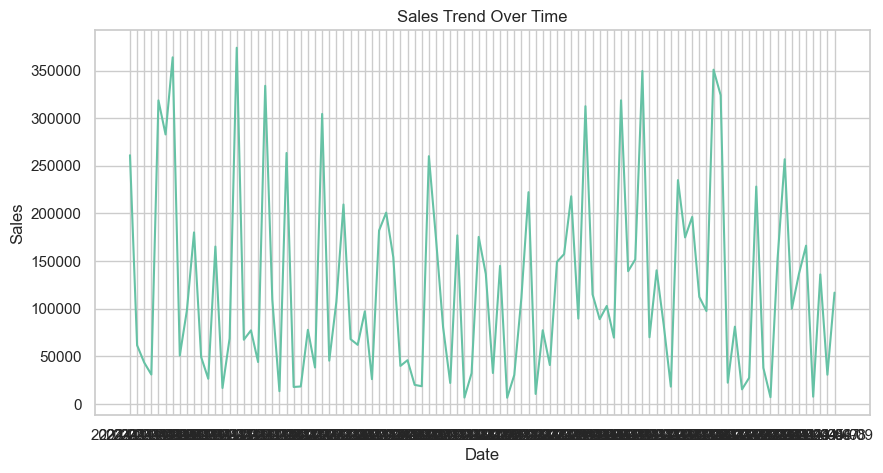

In [ ]:

plt.figure(figsize=(10,5))
sns.lineplot(data=df, x='Date', y='Total_Sales')
plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()


📊 Sales by Category

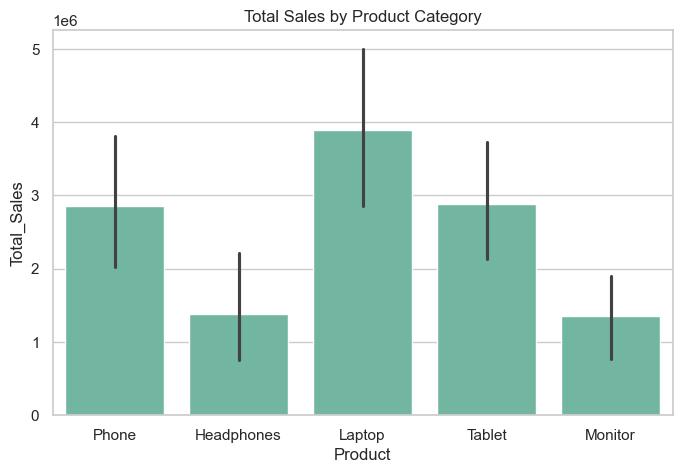

In [ ]:

plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Product', y='Total_Sales', estimator=np.sum)
plt.title("Total Sales by Product Category")
plt.show()


🔹 5. Day 2 – Statistical Visualizations

📦 Box Plot

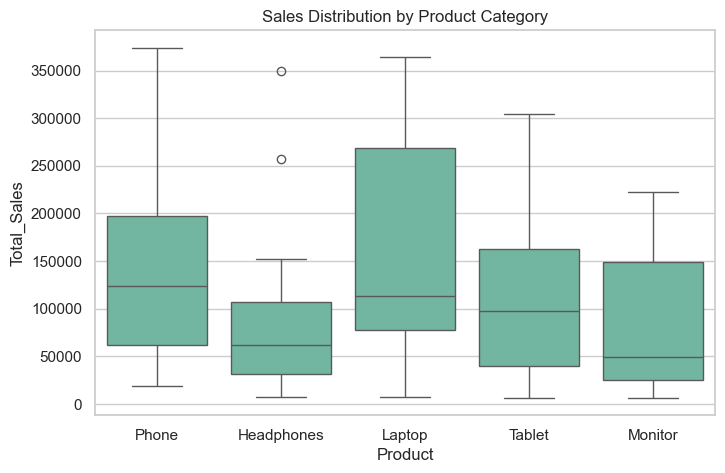

In [ ]:

plt.figure(figsize=(8,5))
sns.boxplot(x='Product', y='Total_Sales', data=df)
plt.title("Sales Distribution by Product Category")
plt.show()


🎻 Violin Plot

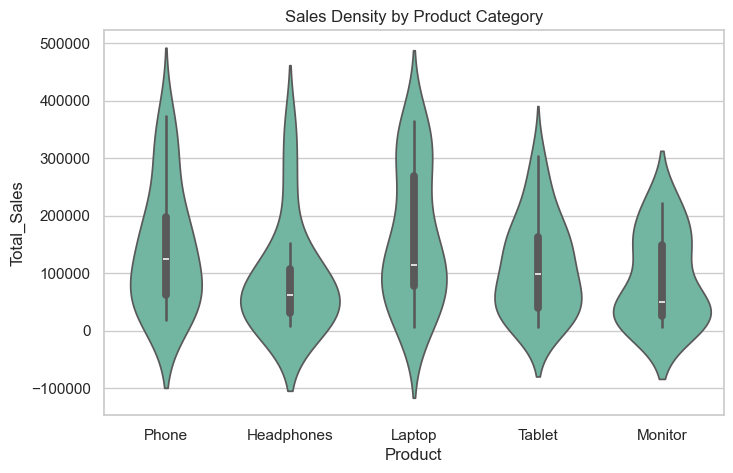

In [ ]:

plt.figure(figsize=(8,5))
sns.violinplot(x='Product', y='Total_Sales', data=df)
plt.title("Sales Density by Product Category")
plt.show()


🔹 6. Day 3 – Heatmaps & Correlation

🔥 Correlation Heatmap

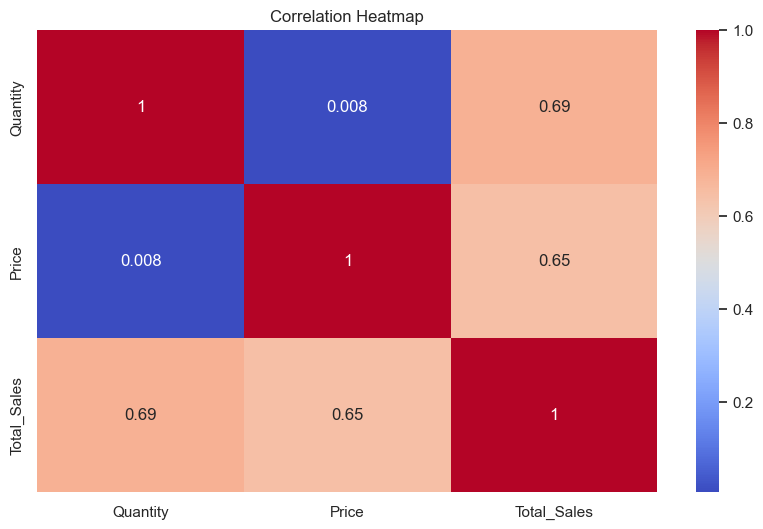

In [ ]:
plt.figure(figsize=(10,6))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


🔹 7. Day 4 – Multi-Plot Dashboard (2×2 Grid)

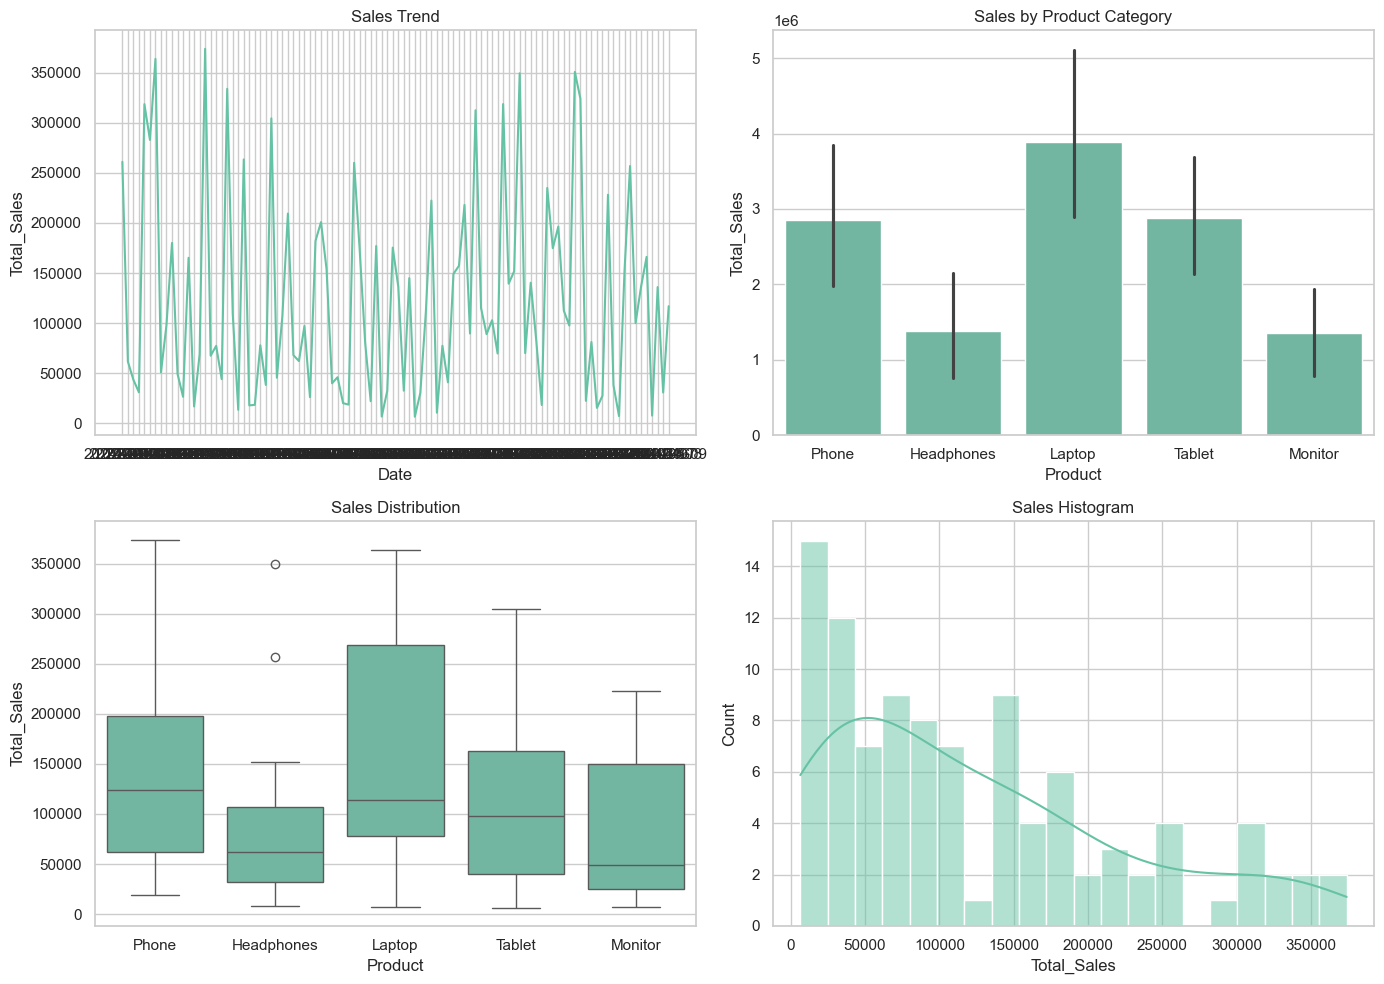

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

sns.lineplot(ax=axes[0,0], data=df, x='Date', y='Total_Sales')
axes[0,0].set_title("Sales Trend")

sns.barplot(ax=axes[0,1], data=df, x='Product', y='Total_Sales', estimator=np.sum)
axes[0,1].set_title("Sales by Product Category")
sns.boxplot(ax=axes[1,0], data=df, x='Product', y='Total_Sales')
axes[1,0].set_title("Sales Distribution")

sns.histplot(ax=axes[1,1], data=df, x='Total_Sales', bins=20, kde=True)
axes[1,1].set_title("Sales Histogram")

plt.tight_layout()
plt.show()


🔹 8. Day 5 – Interactive Visualizations (Plotly)

🖱️ Interactive Sales Trend

In [ ]:
fig = px.line(
    df,
    x="Date",
    y="Total_Sales",
    color="Product",
    title="Interactive Sales Trend"
)
fig.show()


🧩 Product Performance

In [ ]:
fig = px.bar(
    df,
    x="Product",
    y="Total_Sales",
    color="Product",
    title="Product Performance Dashboard"
)
fig.show()


🔄 Dropdown Filter

In [ ]:
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "Sales Trend Over Time",
        "Sales by Category",
        "Sales Distribution",
        "Sales by Quantity"
    )
)

# Sales trend
fig.add_trace(
    go.Scatter(
        x=df['Date'],
        y=df['Total_Sales'],
        mode='lines',
        name='Sales'
    ),
    row=1, col=1
)
# Category sales
category_sales = df.groupby('Product')['Total_Sales'].sum().reset_index()
fig.add_trace(
    go.Bar(
        x=category_sales['Product'],
        y=category_sales['Total_Sales'],
        name='Category Sales'
    ),
    row=1, col=2
)

# Sales distribution
fig.add_trace(
    go.Box(
        y=df['Total_Sales'],
        name='Sales Distribution'
    ),
    row=2, col=1
)

# Sales vs Quantity (if Quantity exists)
if 'Quantity' in df.columns:
    fig.add_trace(
        go.Scatter(
            x=df['Quantity'],
            y=df['Total_Sales'],
            mode='markers',
            name='Quantity vs Sales'
        ),
        row=2, col=2
    )

fig.update_layout(
    height=800,
    title="Interactive Sales Dashboard"
)

fig.show()